# **EDA Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT1",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT1/data


---
## Student Information


In [2]:
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [3]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install "vegafusion"
!pip install "vl-convert-python>=1.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 14.5 MB/s eta 0:00:00


### 0.b Import Packages

In [6]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import altair as alt

In [7]:
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

---
## A. Project Description


In [8]:
business_objective = """

GOAL OF THE PROJECT:
To build a machine learning model that predicts the fair market price of a used
vehicle for consumers planning on buying it. Say, someone finds a car on Gumtree
or Facebook Marketplace, they'll just have to enter some specs of the car, and
the model will tell them whether the asking price is reasonable or overpriced.

HOW THE RESULTS WILL BE USED:
The buyer can compare the predicted price with the listed price. If the
asking price is significantly higher than the prediction, the buyer gets a
warning that the car may be overpriced. If it's well within the listed price,
it is appropriately priced. If it is lower, they know it could be a good deal
and can use the estimate as leverage when negotiating.

IMPACT OF ACCURATE VS INCORRECT RESULTS:
If the model predicts too high, a buyer ends up overpaying because the model
told them the price was fair when it was not. If it predicts too low, it
flags a genuinely fair listing as overpriced and the buyer walks away from
a good deal.

Both types of errors are bad for the buyer, which is why it is important
to minimise prediction errors. The goal is to keep the model as accurate as
possible so that the buyer can make confident and informed decisions.

"""

In [9]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_objective', value=business_objective)

---
## B. Dataset Understanding (Global Interpretation)

In [10]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Load training data
try:
  training_df = pd.read_csv(at.folder_path / "vehicles_price_training.csv")
  validation_df = pd.read_csv(at.folder_path / "vehicles_price_validation.csv")
  testing_df = pd.read_csv(at.folder_path / "vehicles_price_testing.csv")
except Exception as e:
  print(e)

### B.1 Explore Training Set


> You can add more cells in this section

In [11]:
training_df.shape

(8774, 29)

In [12]:
training_df.columns

Index(['prefix', 'first_name', 'last_name', 'gender', 'phone_number', 'email',
       'vehicle_description', 'vehicle_brand', 'manufacturing_year',
       'model_name', 'vehicle_type', 'vehicle_condition', 'transmission_type',
       'engine_capacity', 'drive_type', 'fuel_type', 'fuel_consumption',
       'kilometres_driven', 'vehicle_colour', 'secondary_address',
       'building_number', 'street_name', 'street_suffix', 'location',
       'engine_cylinders', 'body_type', 'doors', 'seats', 'price'],
      dtype='object')

In [13]:
training_df.head()

,prefix,first_name,last_name,gender,phone_number,email,vehicle_description,vehicle_brand,manufacturing_year,model_name,...,secondary_address,building_number,street_name,street_suffix,location,engine_cylinders,body_type,doors,seats,price
0,Mr.,Jose,Garcia,m,4633-5233,clynch@example.net,2014 Honda Jazz Hybrid,Honda,2014.0,Jazz,...,Unit 41,63,Cox Crest,Mount,"Lidcombe, NSW",4 cyl,Hatchback,5 Doors,5 Seats,17900
1,Dr.,Courtney,Wood,f,+61.432.299.313,ucollins@example.org,2013 Ford Ranger XL 3.2 (4X4),Ford,2013.0,Ranger,...,Level 6,7,Ramirez Deviation,Part,"Caboolture, QLD",5 cyl,Ute / Tray,2 Doors,2 Seats,26990
2,Mrs.,Dumisile,Wasendlunkulu,f,08.3708.3270,shenry@example.org,1978 Porsche 911 SC,Porsche,1978.0,911,...,Unit 17,6,Maria Riviera,Sound,"Medlow Bath, NSW",6 cyl,Convertible,2 Doors,4 Seats,97500
3,Mrs.,Anna,Terry,f,02-7521-6711,mperez@example.org,2006 Honda Accord V6 Luxury,Honda,2006.0,Accord,...,Level 9,9,Davis Nook,Subway,"Lansvale, NSW",6 cyl,Sedan,4 Doors,5 Seats,6949
4,Mrs.,Joanna,Rivera,f,07 9571 6288,kdavis@example.org,2012 Kia Sorento Platinum (4X4),Kia,2012.0,Sorento,...,Apt. 440,511,Donna Underpass,Road,"Ringwood, VIC",4 cyl,SUV,4 Doors,7 Seats,21990


In [14]:
training_df.describe(include = "all")

,prefix,first_name,last_name,gender,phone_number,email,vehicle_description,vehicle_brand,manufacturing_year,model_name,...,secondary_address,building_number,street_name,street_suffix,location,engine_cylinders,body_type,doors,seats,price
count,5922,8774,8774,8774,8774,8774,8774,8774,8774.000000,8774,...,8774,8774.000000,8774,8774,8774,8774,8577,7738,7671,8773
unique,5,988,1542,3,8774,8605,5123,66,NaN,595,...,2311,NaN,8386,200,577,10,9,13,10,1728
top,Mr.,Michael,Smith,f,0360838479,ebrown@example.com,2017 Toyota Hilux SR (4X4),Toyota,NaN,Commodore,...,Level 9,NaN,Johnson Loop,Row,"Minchinbury, NSW",4 cyl,SUV,4 Doors,5 Seats,19990
freq,2021,165,156,2992,1,4,25,1430,NaN,257,...,128,NaN,4,67,513,5564,2915,5602,5630,193
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.463073,NaN,...,NaN,175.218828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.455097,NaN,...,NaN,272.716392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1940.000000,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.000000,NaN,...,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,...,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,...,NaN,205.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8774 entries, 0 to 8773
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   prefix               5922 non-null   object 
 1   first_name           8774 non-null   object 
 2   last_name            8774 non-null   object 
 3   gender               8774 non-null   object 
 4   phone_number         8774 non-null   object 
 5   email                8774 non-null   object 
 6   vehicle_description  8774 non-null   object 
 7   vehicle_brand        8774 non-null   object 
 8   manufacturing_year   8774 non-null   float64
 9   model_name           8774 non-null   object 
 10  vehicle_type         8772 non-null   object 
 11  vehicle_condition    8774 non-null   object 
 12  transmission_type    8774 non-null   object 
 13  engine_capacity      8774 non-null   object 
 14  drive_type           8774 non-null   object 
 15  fuel_type            8774 non-null   o

In [16]:
train_nullval = training_df.isnull().sum()
train_nullval[train_nullval > 0]

,0
prefix,2852
vehicle_type,2
body_type,197
doors,1036
seats,1103
price,1


In [17]:
training_df.duplicated().sum()

np.int64(0)

In [18]:
#visualising the categorical columns to check on its types and counts
cat_cols = ["vehicle_condition", "transmission_type", "body_type",
            "drive_type", "fuel_type"]

for col in cat_cols:
    counts = training_df[col].value_counts().reset_index()
    counts.columns = [col, "count"]

    chart = alt.Chart(counts).mark_bar(color="orange").encode(
        alt.X(f"{col}:N", sort="-y", title=col),
        alt.Y("count:Q", title="Count"),
        tooltip=[col, "count"]
    ).properties(title=col, width=400, height=250)

    display(chart)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [19]:
#plotting the different types of brands available in training data
brand_counts_train = training_df["vehicle_brand"].value_counts().reset_index()
brand_counts_train.columns = ["vehicle_brand", "count"]

alt.Chart(brand_counts_train).mark_bar().encode(
    alt.Y("vehicle_brand:N", sort="-x", title="Brand"),
    alt.X("count:Q", title="Count"),
    tooltip=["vehicle_brand", "count"]
).properties(
    title="Vehicle Brand Counts",
    width=500,
    height=600
)

alt.Chart(...)

In [20]:
# clubbing brands based on the records
brand_counts_train = training_df["vehicle_brand"].value_counts()
print("0-50 records:", (brand_counts_train <= 50).sum(), "brands")
print("51-100 records:", ((brand_counts_train > 50) & (brand_counts_train <= 100)).sum(), "brands")
print("101-200 records:", ((brand_counts_train > 100) & (brand_counts_train <= 200)).sum(), "brands")
print("200+ records:", (brand_counts_train > 200).sum(), "brands")
print()

alt.Chart(pd.DataFrame({"count": brand_counts_train.values})).mark_bar().encode(
    alt.X("count:Q", bin=alt.Bin(maxbins=50), title="Number of Records per Brand"),
    alt.Y("count()", title="Number of Brands"),
    tooltip=["count()"]
).properties(
    title="Distribution of Brand Frequencies",
    width=500,
    height=300
)

0-50 records: 44 brands
51-100 records: 5 brands
101-200 records: 3 brands
200+ records: 14 brands



alt.Chart(...)

In [21]:
# checking counts to decide cutoff
print("Brands with less than 100 records:")
print(brand_counts_train[brand_counts_train < 100])
print(f"\nTotal brands under 100: {(brand_counts_train < 100).sum()}")
print(f"Total records affected: {brand_counts_train[brand_counts_train < 100].sum()}")

Brands with less than 100 records:
vehicle_brand
Isuzu          94
Lexus          79
Volvo          63
Renault        56
Porsche        53
Mini           43
HSV            42
Peugeot        30
Fiat           30
Jaguar         30
Skoda          24
Chrysler       20
Dodge          13
Alfa           12
Citroen        12
Great          11
LDV            11
Maserati        9
Ssangyong       9
Bentley         6
Ferrari         6
FPV             5
Daihatsu        4
Opel            4
MG              4
Chevrolet       3
Mahindra        3
Foton           3
Rover           3
Tesla           2
Infiniti        2
Saab            2
McLaren         2
Chery           2
GWM             2
Aston           2
Ram             1
Geely           1
Lamborghini     1
Haval           1
Smart           1
Rolls-Royce     1
Iveco           1
Tata            1
Hummer          1
Daewoo          1
Datsun          1
Packard         1
Proton          1
Name: count, dtype: int64

Total brands under 100: 49
Total records a

In [22]:
# checking on categorical columns for anything suspicious
cat_cols = ["vehicle_brand", "model_name", "transmission_type",
            "engine_cylinders", "drive_type", "fuel_type", "body_type", "vehicle_type"]

for col in cat_cols:
    print(f"=== {col} ===")
    print(f"Unique values: {training_df[col].nunique()}")
    print()
    print("Top 5")
    print(training_df[col].value_counts().head())
    print()
    print("Bottom 5")
    print(training_df[col].value_counts().tail())
    print()

=== vehicle_brand ===
Unique values: 66

Top 5
vehicle_brand
Toyota    1430
Holden     916
Ford       682
Nissan     667
Mazda      619
Name: count, dtype: int64

Bottom 5
vehicle_brand
Hummer     1
Daewoo     1
Datsun     1
Packard    1
Proton     1
Name: count, dtype: int64

=== model_name ===
Unique values: 595

Top 5
model_name
Commodore      257
Hilux          241
Ranger         211
Landcruiser    200
Navara         176
Name: count, dtype: int64

Bottom 5
model_name
S16       1
CLK280    1
LC500     1
121       1
SL350     1
Name: count, dtype: int64

=== transmission_type ===
Unique values: 3

Top 5
transmission_type
Automatic    7125
Manual       1548
-             101
Name: count, dtype: int64

Bottom 5
transmission_type
Automatic    7125
Manual       1548
-             101
Name: count, dtype: int64

=== engine_cylinders ===
Unique values: 10

Top 5
engine_cylinders
4 cyl    5564
6 cyl    1412
-        1080
8 cyl     384
5 cyl     265
Name: count, dtype: int64

Bottom 5
engine_

In [23]:
#exploring on numerical columns
num_cols = ["manufacturing_year", "kilometres_driven", "price"]

for col in num_cols:
    display(alt.Chart(training_df[[col]].dropna().sample(2000, random_state=42)).mark_bar().encode(
        alt.X(f"{col}:Q", bin=alt.Bin(maxbins=40), title=col),
        alt.Y("count()", title="Count"),
        tooltip=["count()"]
    ).properties(title=col, width=400, height=250))

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [24]:
# checking for suspicious values on numeric data
price_num = pd.to_numeric(
    training_df["price"].astype(str).str.replace(",", ""), errors="coerce"
)
km_num = pd.to_numeric(
    training_df["kilometres_driven"].astype(str).str.replace(",", ""), errors="coerce"
)

print("price range:", "\nMin: $", price_num.min(), "\nMax: $", price_num.max())
print("price under 1000:", (price_num < 1000).sum())
print("price over 500000:", (price_num > 500000).sum())

print("\nkm range:", "\nMin: ", km_num.min(), "kms", "\nMax: ", km_num.max(), "kms")
print("km under 100:", (km_num < 100).sum())
print("km over 400000:", (km_num > 400000).sum())

print("\nyear range:", int(training_df['manufacturing_year'].min()), "-", int(training_df['manufacturing_year'].max()))
print("pre 1990:", (training_df['manufacturing_year'] < 1990).sum())

price range: 
Min: $ 88.0 
Max: $ 1500000.0
price under 1000: 2
price over 500000: 2

km range: 
Min:  1.0 kms 
Max:  533849.0 kms
km under 100: 3
km over 400000: 43

year range: 1940 - 2017
pre 1990: 17


In [25]:
# checking brand_bodytype combination if its a strong influence on price
price_num = pd.to_numeric(
    training_df["price"].astype(str).str.replace(",", ""), errors="coerce"
)

brand_body_price = (
    training_df.assign(
        price_num=price_num,
        brand_bodytype=training_df["vehicle_brand"] + "_" + training_df["body_type"]
    )
    .groupby("brand_bodytype")["price_num"]
    .median().reset_index()
    .rename(columns={"price_num": "median_price"})
    .sort_values("median_price", ascending=False)
)

print(f"Unique brand_bodytype combinations: {brand_body_price.shape[0]}")
print()
print("Top 10:")
print(brand_body_price.head(10))
print()
print("Bottom 10:")
print(brand_body_price.tail(10))

Unique brand_bodytype combinations: 220

Top 10:
          brand_bodytype  median_price
38         Ferrari_Coupe      879940.0
104    Lamborghini_Coupe      649880.0
129  McLaren_Convertible      369880.0
178    Rolls-Royce_Sedan      329990.0
130        McLaren_Coupe      288888.0
37   Ferrari_Convertible      274890.0
167        Porsche_Coupe      221935.0
17   Bentley_Convertible      209990.0
32           Dodge_Coupe      179990.0
18         Bentley_Coupe      159945.0

Bottom 10:
        brand_bodytype  median_price
21           Chery_SUV        7999.0
171       Proton_Sedan        7990.0
164      Peugeot_Sedan        7990.0
54      GWM_Ute / Tray        7750.0
194  Suzuki_Commercial        6999.0
1           Alfa_Sedan        6489.0
20     Chery_Hatchback        5990.0
185        Smart_Coupe        5985.0
180         Saab_Sedan        5400.0
30        Daewoo_Sedan         900.0


In [26]:
# plot brand only vs brand+bodytype side by side
brand_price = (
    training_df.assign(price_num=price_num)
    .groupby("vehicle_brand")["price_num"]
    .median().reset_index()
    .rename(columns={"price_num": "median_price"})
    .sort_values("median_price", ascending=False)
)

chart1 = alt.Chart(brand_price.head(20)).mark_bar(color="#2E86AB").encode(
    alt.Y("vehicle_brand:N", sort="-x", title="Brand"),
    alt.X("median_price:Q", title="Median Price (AUD)"),
    tooltip=["vehicle_brand", "median_price"]
).properties(
    title="Brand Only",
    width=350,
    height=400
)

top_bottom = pd.concat([brand_body_price.head(20), brand_body_price.tail(20)])

chart2 = alt.Chart(top_bottom).mark_bar(color="#E84855").encode(
    alt.Y("brand_bodytype:N", sort="-x", title="Brand + Body Type"),
    alt.X("median_price:Q", title="Median Price (AUD)"),
    tooltip=["brand_bodytype", "median_price"]
).properties(
    title="Brand + Body Type",
    width=350,
    height=400
)

chart1 | chart2

alt.HConcatChart(...)

In [27]:
training_set_insights = """

DIMENSIONS:
The training set has 8,774 rows and 29 columns.

COLUMN OVERVIEW:
12 out of 29 columns are personal owner information such as names, addresses,
phone numbers, email, etc. They will be dropped in the preparation notebook as
they are not useful in predicting price and keeping them would raise privacy
concerns.
The remaining 17 columns are vehicle features including the target variable
price.

MISSING VALUES:
1. vehicle_type: 2 missing - will impute with mode
2. body_type: 197 missing - will impute with mode
3. doors: 1,036 missing - will not consider for model training due to too many
missing values and can be derived from the body_type of the car
4. seats: 1,103 missing - will not consider for model training due to too many
missing values and wrong data such as 11 and 14 seats
5. price: 1 missing - row will be dropped since it is the target, it can't be
imputed and dropping 1 row would not harm model training
6. transmission_type - '-' values will impute with mode

DATA TYPE ISSUES:
Several columns that look numeric are stored as strings. fuel_consumption has
values like 9.2 L / 100 km. All need to be cleaned and converted to float before
modelling.

SUSPICIOUS VALUES:
Price ranges from $88 to $1,500,000. There are 2 records under $1,000 and 2 records
over $500,000. The records under $1,000 are mostly wrong information and will be
dropped. The 2 values above $500,000 are legitimate exotic cars and would not
represent the usual car market. So, it becomes really important to map them
correctly and I predict that these outlier values can hinder the model
performance. kilometres_driven ranges from 1 km to 533,849 km. There are 3
records under 100 km which is suspicious for a used car, and 43 records over
400,000 km are outliers. manufacturing_year ranges from 1940 to 2017.
There are 17 vehicles made before 1990 which are likely classic cars and may not
follow the same pricing patterns as regular used cars.
All suspicious records will be reviewed and handled in the Preparation notebook.

GROUPING BRANDS AND OBSERVATIONS:
There are 66 unique brands in the dataset. I explored different cutoffs
for grouping less occuring brands as "Other".
At a cutoff of 100 records, 49 brands would be grouped as "Other" but this
included well known brands like Porsche, Jaguar, Lexus and Volvo which
have distinct pricing patterns and cannot be grouped as "Other".
Lowering the cutoff to 50 records, 44 brands would be grouped but brands
like Mini, Renault and Volvo were still getting affected.
At a cutoff of 10 records, only 32 brands with 86 total records would be
grouped. But even here brands like Aston Martin and Rolls-Royce would be
affected. These are extremely expensive cars that sell in low volumes by
nature, grouping them with obscure less count brands as "Other" would cause the
model to massively underestimate their price since the "Other" average would be
pulled down by all the cheaper unknown brands.To avoid this problem entirely,
target encoding or similar techniques will be used in the Preparation notebook
instead. Initially I thought encoding vehicle_brand using just the mean price per
brand would be a good approach. However I realised this was too simple. A
brand like Toyota has both cheap Corollas and expensive Land Cruisers, so
averaging all Toyotas together into one number would lose a lot of important
pricing information and mislead the model.

To fix this, I will be combining vehicle_brand with body_type to create a
new feature called brand_bodytype in the Preparation notebook. This
captures the fact that the same brand can have both cheap and expensive
models depending on the body type, for example a Toyota Hatchback and
a Toyota SUV are priced very differently. This combined feature will
then be encoded using mean prices from training, giving the model a much more
specific and meaningful signal than brand alone.
Also validated it in a comparison plot of the median price for brand only vs
brand combined with body type. The brand only plot showed Lamborghini at
the top whereas the brand + body type plot revealed that the same brands appear
at very different price points depending on body type, for example Porsche Coupe
vs Porsche Convertible sit at completely different price levels now. The bottom of
the chart also showed combinations like Daewoo Sedan at $900 and Saab Sedan at
$5,400 which would have been completely hidden if we just used the brand average.
With 220 unique brand + body type combinations ranging from $900 to $879,940,
this feature clearly captures much richer pricing information than brand alone.

OTHER OBSERVATIONS:
vehicle_condition is almost entirely USED with only 5 records saying NEW
so this column probably will not add much predictive power.
model_name has 595 unique values with many appearing only once. This column
is too granular to use reliably and will be dropped in Preparation.
transmission_type has 101 records with a dash as a placeholder for unknown.
These will be replaced with Automatic since it is the dominant class.
vehicle_type has 307 unique values and the least common ones are clearly
dealership names rather than vehicle types. This column will be dropped
and body_type used instead which is cleaner and consistent across all splits.
No duplicate rows found.

"""

In [28]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='training_set_insights', value=training_set_insights)

### B.2 Explore Validation Set

> You can add more cells in this section

In [29]:
validation_df.shape

(2615, 29)

In [30]:
validation_df.head()

,prefix,first_name,last_name,gender,phone_number,email,vehicle_description,vehicle_brand,manufacturing_year,model_name,...,secondary_address,building_number,street_name,street_suffix,location,engine_cylinders,body_type,doors,seats,price
0,Mrs.,Brenda,Sullivan,f,03-5091-4887,orichards@example.net,2020 Land Rover Range Rover Velar P250 R-Dynam...,Land,2020.0,Rover,...,Level 7,2,Gabrielle Close,Bypass,"Chatswood, NSW",4 cyl,SUV,4 Doors,5 Seats,95880
1,Mrs.,Kristen,Bauer,f,(02)-9028-3801,dsanchez@example.com,2020 Mercedes-Benz Vito 116 CDI SWB,Mercedes-Benz,2020.0,Vito,...,Suite 530,1,Fernandez Strip,Subway,"Coburg North, VIC",4 cyl,Commercial,2 Doors,2 Seats,46990
2,Dr.,Dana,Cantu,f,(08)56508629,bassalexis@example.org,2019 Volkswagen Amarok V6 TDI 580 Ultimate,Volkswagen,2019.0,Amarok,...,Flat 18,197,Miller Retreat,Pass,"Clarkson, WA",6 cyl,Ute / Tray,4 Doors,5 Seats,51888
3,NaN,Jacqueline,Smith,u,(08)20343189,vmoore@example.com,2019 Toyota Hilux SR5 (4X4),Toyota,2019.0,Hilux,...,Level 2,7,Jeremiah Arcade,Triangle,"North Wollongong, NSW",4 cyl,Ute / Tray,2 Doors,4 Seats,55990
4,Mr.,Ian,Archer,m,(03).3070.1158,emorgan@example.com,2020 Mitsubishi Triton GSR (4X4),Mitsubishi,2020.0,Triton,...,6/,538,Ho Highway,Riverway,"Shepparton, VIC",4 cyl,Ute / Tray,4 Doors,5 Seats,51990


In [31]:
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2615 entries, 0 to 2614
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   prefix               1715 non-null   object 
 1   first_name           2615 non-null   object 
 2   last_name            2614 non-null   object 
 3   gender               2615 non-null   object 
 4   phone_number         2615 non-null   object 
 5   email                2615 non-null   object 
 6   vehicle_description  2615 non-null   object 
 7   vehicle_brand        2615 non-null   object 
 8   manufacturing_year   2615 non-null   float64
 9   model_name           2615 non-null   object 
 10  vehicle_type         2615 non-null   object 
 11  vehicle_condition    2615 non-null   object 
 12  transmission_type    2615 non-null   object 
 13  engine_capacity      2615 non-null   object 
 14  drive_type           2615 non-null   object 
 15  fuel_type            2615 non-null   o

In [32]:
val_nullval = validation_df.isnull().sum()
val_nullval[val_nullval > 0]

,0
prefix,900
last_name,1
body_type,30
doors,138
seats,143


In [33]:
validation_df.duplicated().sum()

np.int64(0)

In [34]:
#plotting the different types of brands available in validation data
brand_counts_val = validation_df["vehicle_brand"].value_counts().reset_index()
brand_counts_val.columns = ["vehicle_brand", "count"]

alt.Chart(brand_counts_val).mark_bar().encode(
    alt.Y("vehicle_brand:N", sort="-x", title="Brand"),
    alt.X("count:Q", title="Count"),
    tooltip=["vehicle_brand", "count"]
).properties(
    title="Vehicle Brand Counts",
    width=500,
    height=600
)

alt.Chart(...)

In [35]:
print("Training vehicle_condition:")
print(training_df["vehicle_condition"].value_counts())
print()
print("Validation vehicle_condition:")
print(validation_df["vehicle_condition"].value_counts())
print()
print("Testing vehicle_condition:")
print(testing_df["vehicle_condition"].value_counts())


Training vehicle_condition:
vehicle_condition
USED    8769
NEW        5
Name: count, dtype: int64

Validation vehicle_condition:
vehicle_condition
USED    2614
NEW        1
Name: count, dtype: int64

Testing vehicle_condition:
vehicle_condition
NEW     1220
USED     922
DEMO     505
Name: count, dtype: int64


In [36]:
#visualising the categorical columns to check on its types and counts
cat_cols = ["vehicle_condition", "transmission_type", "body_type",
            "drive_type", "fuel_type"]

for col in cat_cols:
    counts = validation_df[col].value_counts().reset_index()
    counts.columns = [col, "count"]

    chart = alt.Chart(counts).mark_bar(color="orange").encode(
        alt.X(f"{col}:N", sort="-y", title=col),
        alt.Y("count:Q", title="Count"),
        tooltip=[col, "count"]
    ).properties(title=col, width=400, height=250)

    display(chart)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [37]:
cat_cols = ["vehicle_brand", "model_name", "transmission_type",
            "engine_cylinders", "drive_type", "fuel_type", "body_type", "vehicle_type"]

for col in cat_cols:
    print(f"=== {col} ===")
    print(f"Unique values: {validation_df[col].nunique()}")
    print(validation_df[col].value_counts().tail(5))
    print()

=== vehicle_brand ===
Unique values: 46
vehicle_brand
Lamborghini    1
Daihatsu       1
GWM            1
Chevrolet      1
Maserati       1
Name: count, dtype: int64

=== model_name ===
Unique values: 274
model_name
UX        1
CLA200    1
GLE       1
M140I     1
GLE400    1
Name: count, dtype: int64

=== transmission_type ===
Unique values: 3
transmission_type
Automatic    2478
Manual        112
-              25
Name: count, dtype: int64

=== engine_cylinders ===
Unique values: 9
engine_cylinders
3 cyl     62
5 cyl     55
0 L       13
12 cyl     1
10 cyl     1
Name: count, dtype: int64

=== drive_type ===
Unique values: 5
drive_type
Front    1340
AWD       531
4WD       475
Rear      182
Other      87
Name: count, dtype: int64

=== fuel_type ===
Unique values: 7
fuel_type
Premium     461
Hybrid      191
-            32
Electric     14
Other         3
Name: count, dtype: int64

=== body_type ===
Unique values: 10
body_type
Commercial      71
Coupe           31
Convertible      7
Other 

In [38]:
brand_counts_val = validation_df["vehicle_brand"].value_counts()

alt.Chart(pd.DataFrame({"count": brand_counts_val.values})).mark_bar().encode(
    alt.X("count:Q", bin=alt.Bin(maxbins=50), title="Number of Records per Brand"),
    alt.Y("count()", title="Number of Brands"),
    tooltip=["count()"]
).properties(
    title="Distribution of Brand Frequencies",
    width=500,
    height=300
)

alt.Chart(...)

In [39]:
# checking on suspicious values
val_price_num = pd.to_numeric(
    validation_df["price"].astype(str).str.replace(",", ""), errors="coerce"
)
val_km_num = pd.to_numeric(
    validation_df["kilometres_driven"].astype(str).str.replace(",", ""), errors="coerce"
)

print("price range:", "\nMin: $", val_price_num.min(), "\nMax: $", val_price_num.max())
print("price under 1000:", (val_price_num < 1000).sum())
print("price over 500000:", (val_price_num > 500000).sum())

print("\nkm range:", "\nMin: ", val_km_num.min(), "kms", "\nMax: ", val_km_num.max(), "kms")
print("km under 100:", (val_km_num < 100).sum())
print("km over 400000:", (val_km_num > 400000).sum())

print("\nyear range:", int(validation_df['manufacturing_year'].min()), "-", int(validation_df['manufacturing_year'].max()))
print("pre 1990:", (validation_df['manufacturing_year'] < 1990).sum())


price range: 
Min: $ 12990.0 
Max: $ 649880.0
price under 1000: 0
price over 500000: 2

km range: 
Min:  12 kms 
Max:  347128 kms
km under 100: 1
km over 400000: 0

year range: 2019 - 2020
pre 1990: 0


In [40]:
validation_set_insights = """

DIMENSIONS:
The validation set has 2,615 rows and 29 columns

MISSING VALUES:
body_type has 30 missing values, doors has 138 missing values and seats has 143
missing values.

SUSPICIOUS VALUES:
Price ranges from $12,990 to $649,880. No records under $1,000 which is cleaner
than training. There are 2 records over $500,000 similar to training.
kilometres_driven ranges from 12 km to 347,128 km. Only 1 record under 100 km
and no records over 400,000 km, also cleaner than training.

OBSERVATIONS:
I also observed that training data had vehicles till 2017 while validation data
has from 2019-2020 vehicles. This means the model will be predicting price on
manufacturing years it has never seen during training. If manufacturing_year
is a dominant feature this gap would likely hurt the performance significantly.
If the model itself performs better on validation data, it shows that other
features had more weight compared to manufaxturing_year while training the model.

The test set has a completely different vehicle condition distribution compared
to training and validation. Training had 99.9% USED cars while the test set has
47% NEW, 36% USED and 19% DEMO. The model will be trained almost entirely on
used car pricing patterns and will be evaluated on a majority of new and demo
vehicles which follow completely different pricing rules. This data distribution
shift can affect RMSE significantly.

CHANGES CARRIED OVER FROM TRAINING:
The following steps from training will be applied to validation data using
parameters learned from training data. Because using validation data to
calculate these would mean data leakage, the model would have indirectly seen
validation data which would make performance metrics unreliable.
1. All personal detail columns will be dropped.
2. price and kilometres_driven will be parsed from string to float
3. body_type impute with mode from training data, doors and seats will not be
taken into model training
4. transmission_type dash values will be imputed with mode
5. model_name will be dropped as it is of less sifnificance

"""

In [41]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='validation_set_insights', value=validation_set_insights)

### B.3 Explore Testing Set

> You can add more cells in this section

In [42]:
testing_df.shape

(2647, 29)

In [43]:
testing_df.head()

,prefix,first_name,last_name,gender,phone_number,email,vehicle_description,vehicle_brand,manufacturing_year,model_name,...,secondary_address,building_number,street_name,street_suffix,location,engine_cylinders,body_type,doors,seats,price
0,Dr.,Nicole,Welch,f,+61-2-3039-1161,hoffmanrebecca@example.net,2022 Mazda CX-5 Touring (awd),Mazda,2022.0,CX-5,...,Unit 73,0,Dustin Crescent,Roadside,"Lismore, NSW",4 cyl,SUV,4 Doors,5 Seats,49452
1,Dr.,Angie,Stanton,f,+61 3 6700 0872,emily99@example.net,2022 Haval H6 Ultra,Haval,2022.0,H6,...,Apt. 032,6,Robert Fire Track,Thoroughfare,"Port Macquarie, NSW",-,SUV,NaN,NaN,41485
2,Mrs.,Debra,Moses,f,+61363464018,zestes@example.com,2023 Genesis G70 3.3T Sport,Genesis,2023.0,G70,...,Unit 26,1,Holmes Grange,Circuit,NaN,6 cyl,Sedan,4 Doors,5 Seats,75067
3,Mr.,John,Rosales,m,(08) 3540 0274,clinemitchell@example.com,2023 Isuzu MU-X LS-T (4X4),Isuzu,2023.0,MU-X,...,251/,7,Kelly Corso,Quay,"Blacktown, NSW",4 cyl,SUV,4 Doors,7 Seats,75890
4,NaN,Jennifer,Lee,u,(03)-1580-4405,brian65@example.net,2023 Subaru WRX (AWD),Subaru,2023.0,WRX,...,984/,545,Thomas Siding,Byway,NaN,4 cyl,Sedan,4 Doors,5 Seats,45990


In [44]:
testing_df.describe(include = "all")

,prefix,first_name,last_name,gender,phone_number,email,vehicle_description,vehicle_brand,manufacturing_year,model_name,...,secondary_address,building_number,street_name,street_suffix,location,engine_cylinders,body_type,doors,seats,price
count,1785,2647,2647,2647,2647,2647,2647,2647,2647.000000,2647,...,2647,2647.000000,2647,2647,2198,2647,2625,2364,2347,2647
unique,5,638,960,3,2647,2633,1395,55,NaN,319,...,1141,NaN,2608,200,280,9,10,8,11,1515
top,Mr.,Michael,Smith,m,0446.451.629,emartinez@example.com,2022 GWM Haval Jolion Ultra Hybrid,Toyota,NaN,Haval,...,5/,NaN,Michael Turn,Gate,"Blacktown, NSW",4 cyl,SUV,4 Doors,5 Seats,POA
freq,643,66,54,914,1,2,16,291,NaN,115,...,42,NaN,3,21,82,1847,1458,1723,1771,41
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.498300,NaN,...,NaN,192.398187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500092,NaN,...,NaN,286.467988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,...,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,...,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,NaN,...,NaN,292.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
testing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2647 entries, 0 to 2646
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   prefix               1785 non-null   object 
 1   first_name           2647 non-null   object 
 2   last_name            2647 non-null   object 
 3   gender               2647 non-null   object 
 4   phone_number         2647 non-null   object 
 5   email                2647 non-null   object 
 6   vehicle_description  2647 non-null   object 
 7   vehicle_brand        2647 non-null   object 
 8   manufacturing_year   2647 non-null   float64
 9   model_name           2647 non-null   object 
 10  vehicle_type         2622 non-null   object 
 11  vehicle_condition    2647 non-null   object 
 12  transmission_type    2647 non-null   object 
 13  engine_capacity      2647 non-null   object 
 14  drive_type           2647 non-null   object 
 15  fuel_type            2647 non-null   o

In [46]:
test_nullval = testing_df.isnull().sum()
test_nullval[test_nullval > 0]

,0
prefix,862
vehicle_type,25
location,449
body_type,22
doors,283
seats,300


In [47]:
testing_df.duplicated().sum()

np.int64(0)

In [48]:
cat_cols = ["vehicle_condition", "transmission_type", "body_type",
            "drive_type", "fuel_type"]

for col in cat_cols:
    counts = testing_df[col].value_counts().reset_index()
    counts.columns = [col, "count"]

    chart = alt.Chart(counts).mark_bar(color="orange").encode(
        alt.X(f"{col}:N", sort="-y", title=col),
        alt.Y("count:Q", title="Count"),
        tooltip=[col, "count"]
    ).properties(title=col, width=400, height=250)

    display(chart)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [49]:
brand_counts_test = testing_df["vehicle_brand"].value_counts().reset_index()
brand_counts_test.columns = ["vehicle_brand", "count"]

alt.Chart(brand_counts_test).mark_bar().encode(
    alt.Y("vehicle_brand:N", sort="-x", title="Brand"),
    alt.X("count:Q", title="Count"),
    tooltip=["vehicle_brand", "count"]
).properties(
    title="Vehicle Brand Counts",
    width=500,
    height=600
)

alt.Chart(...)

In [50]:
brand_counts_test = testing_df["vehicle_brand"].value_counts()

alt.Chart(pd.DataFrame({"count": brand_counts_test.values})).mark_bar().encode(
    alt.X("count:Q", bin=alt.Bin(maxbins=50), title="Number of Records per Brand"),
    alt.Y("count()", title="Number of Brands"),
    tooltip=["count()"]
).properties(
    title="Distribution of Brand Frequencies",
    width=500,
    height=300
)

alt.Chart(...)

In [51]:
num_cols = ["manufacturing_year", "kilometres_driven", "price"]

for col in num_cols:
    display(alt.Chart(testing_df[[col]].dropna().sample(2000, random_state=42)).mark_bar().encode(
        alt.X(f"{col}:Q", bin=alt.Bin(maxbins=40), title=col),
        alt.Y("count()", title="Count"),
        tooltip=["count()"]
    ).properties(title=col, width=400, height=250))

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [52]:
testing_set_insights = """

DIMENSIONS:
The test set has 2,647 rows and 29 columns.

MISSING VALUES:
location has 449 missing values. I had planned to drop this due to privacy
concerns but this confirms that location should not be used as a feature
since it cannot be relied on during prediction. vehicle_type has 25
missing, body_type has 22 missing, doors has 283 missing and seats has
300 missing.

SUSPICIOUS VALUES:
kilometres_driven ranges from 1 km to 53,960 km. There are 929 records
under 100 km which is very high compared to training (3 records) and
validation (1 record). However unlike training where the 3 low km
records were suspicious old used cars, the 929 low km records in test
are all legitimate brand new/demo 2022-2023 vehicles with genuinely low
mileage.

OBSERVATIONS:
No duplicates found. The test set covers 2022-2023 vehicles continuing
the time based split where training had up to 2017 and validation had
2019-2020.

The vehicle condition distribution is completely different from training and
validation:
- Training  : 99.9% USED, 0.1% NEW, 0% DEMO
- Validation: 99.9% USED, 0.1% NEW, 0% DEMO
- Testing   : 36% USED, 47% NEW, 19% DEMO

I planned on dropping vehicle_condition as a feature as it was near constant in
training and validation at 99.9% USED. This seemed reasonable but the test data
reveals that it was a significant oversight. DEMO did not appear in training or
validation at all.

But now that we are aware of the split on the test data, we can confidently say
that the model would not perform well on the test set as it have not been exposed
to somany NEW and DEMO car lsitings during training of the model. So the model
will find it difficult to predict accurately on those cars.

SCOPE LIMITATION:
Based on this finding the current model should only be used for USED
vehicle price predictions. For the business use case of a used car price validator
on platforms like Gumtree or Facebook Marketplace this is acceptable since most
listings on these platforms are used vehicles. NEW and DEMO vehicle pricing is
better obtained directly from dealerships or manufacturer websites.

This issue can be addressed like;
1. Collect significantly more NEW and DEMO car records in training
   data. Currently only 5 NEW records exist in training which is
   far too few for the model to learn new car pricing patterns.
2. Include vehicle_condition as a feature in the model. As NEW and DEMO are almost
   the samewe could create a binary flag is_used (1=USED, 0=NEW/DEMO) so the model
   knows what type of vehicle it is predicting which could help reduce the RMSE
   overall on test data.

OTHER ISSUES:
As the data is split on model_year, even that poses a problem bacuse of the hike
in market prices overtime, but these are to be expected and can be eventually
made better by feeding in latest data.

CHANGES CARRIED OVER FROM TRAINING:
All preprocessing steps use parameters calculated from training data
to avoid data leakage:
1. All personal detail columns will be dropped
2. price and kilometres_driven will be parsed from string to float
3. body_type will be filled with mode from training
4. transmission_type dash values will be replaced with mode from training
This dataset will only be used to evaluate the final model performance.
5. model_name will be dropped as it is of less sifnificance

"""

In [53]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='testing_set_insights', value=testing_set_insights)

---
## C. Feature Understanding (Local Interpretation)

### C.1 Explore Target Variable

> Save the name of column used as the target variable and call it `target_name`

> You can add more cells in this section

In [54]:
target_name = "price"
print("Target variable:", target_name)
print()
#parsing it to float just for the sake of exploration.
price_num = pd.to_numeric(
    training_df["price"].astype(str).str.replace(",", ""), errors="coerce"
)
print(price_num.describe().round(2))
print(f"\nMissing values: {price_num.isna().sum()}")
print(f"Count of cars listed under $1,000: {(price_num < 1000).sum()}")
print(f"Count of cars listed over $500,000: {(price_num > 500000).sum()}")

Target variable: price

count       8767.00
mean       24733.02
std        26148.87
min           88.00
25%        13990.00
50%        19990.00
75%        29789.50
max      1500000.00
Name: price, dtype: float64

Missing values: 7
Count of cars listed under $1,000: 2
Count of cars listed over $500,000: 2


In [55]:
#checking on the 7 missing values we could not identify before
failed_idx = price_num[price_num.isna()].index
print(training_df.loc[failed_idx, "price"].values)

[nan 'POA' 'POA' 'POA' 'POA' 'POA' 'POA']


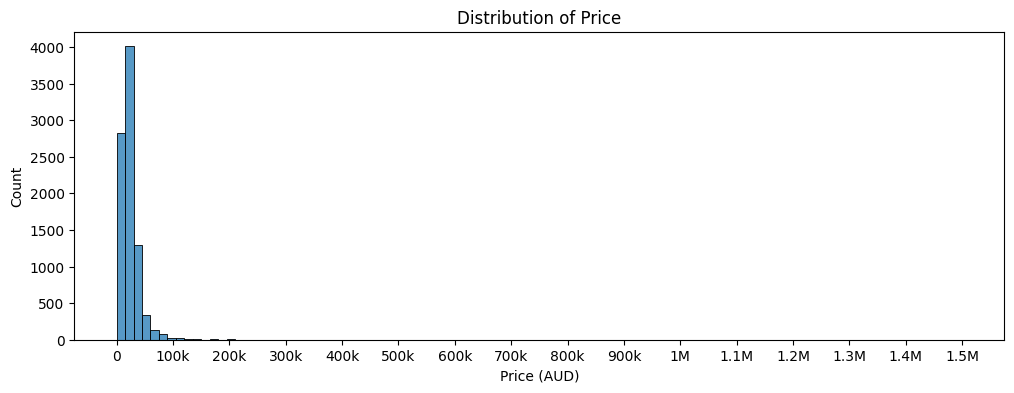

In [56]:
plt.figure(figsize=(12, 4))
sns.histplot(price_num.dropna(), bins=100)
plt.title("Distribution of Price")
plt.xlabel("Price (AUD)")
plt.ylabel("Count")
plt.xticks([0, 100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000, 1100000, 1200000, 1300000, 1400000, 1500000],
           ['0', '100k', '200k', '300k', '400k', '500k', '600k', '700k', '800k', '900k', '1M', '1.1M', '1.2M', '1.3M', '1.4M', '1.5M'])
plt.show()

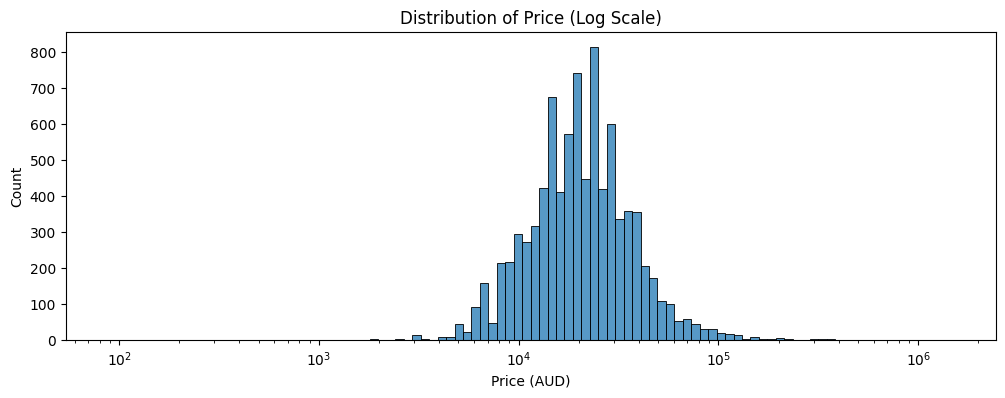

In [57]:
#plotting with log(price)
plt.figure(figsize=(12, 4))
sns.histplot(price_num.dropna(), bins=100, log_scale=True)
plt.title("Distribution of Price (Log Scale)")
plt.xlabel("Price (AUD)")
plt.ylabel("Count")
plt.show()

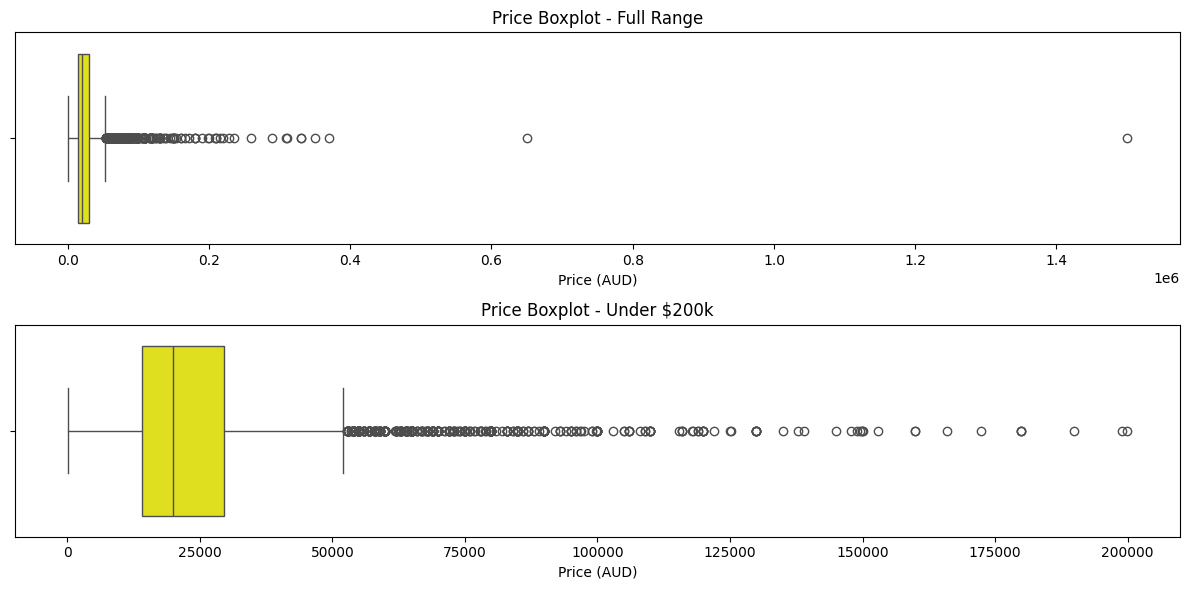

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# full range
sns.boxplot(x=price_num.dropna(), color="yellow", ax=axes[0])
axes[0].set_title("Price Boxplot - Full Range")
axes[0].set_xlabel("Price (AUD)")

# capped at 200k
sns.boxplot(x=price_num[price_num < 200000].dropna(), color="yellow", ax=axes[1])
axes[1].set_title("Price Boxplot - Under $200k")
axes[1].set_xlabel("Price (AUD)")

plt.tight_layout()
plt.show()

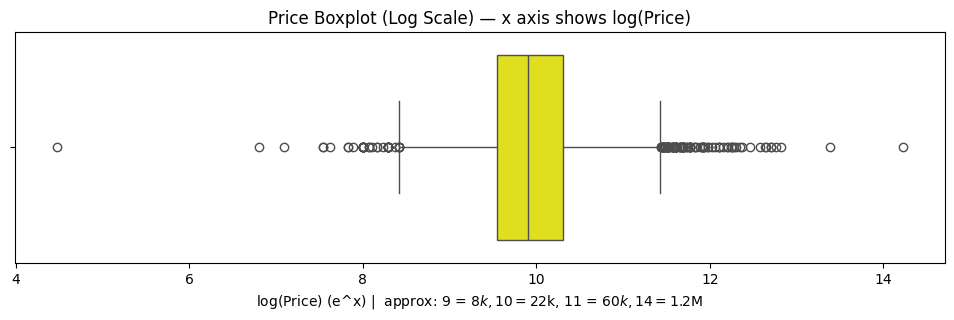

In [59]:
plt.figure(figsize=(12, 3))
sns.boxplot(x=np.log(price_num.dropna()), color="yellow")
plt.title("Price Boxplot (Log Scale) — x axis shows log(Price)")
plt.xlabel("log(Price) (e^x) |  approx: 9 = $8k, 10 = $22k, 11 = $60k, 14 = $1.2M")
plt.show()

In [60]:
# looking at the most expensive records
top10 = training_df.assign(price_num=price_num).nlargest(10, "price_num")
print("Top 10 most expensive cars:")
print(top10[["vehicle_brand", "model_name", "body_type", "manufacturing_year", "kilometres_driven", "price"]])

print()

# looking at the cheapest records
bottom10 = training_df.assign(price_num=price_num).nsmallest(10, "price_num")
print("Bottom 10 cheapest cars:")
print(bottom10[["vehicle_brand", "model_name", "body_type", "manufacturing_year", "kilometres_driven", "price"]])

Top 10 most expensive cars:
      vehicle_brand  model_name    body_type  manufacturing_year  \
1078        Ferrari         250        Coupe              1959.0   
2000    Lamborghini   Aventador        Coupe              2012.0   
3155        McLaren        650S  Convertible              2016.0   
8718        Ferrari  California  Convertible              2017.0   
4054    Rolls-Royce       Ghost        Sedan              2011.0   
1603        Ferrari        F430  Convertible              2008.0   
2800        Porsche         911        Coupe              2007.0   
193   Mercedes-Benz     Maybach        Sedan              2017.0   
1820        McLaren        570S        Coupe              2017.0   
1301        Ferrari         612        Coupe              2005.0   

     kilometres_driven    price  
1078              9902  1500000  
2000             27843   649880  
3155              1116   369880  
8718             12162   349990  
4054             45385   329990  
1603             14

In [61]:
target_insights = """

price has been set as the target_variable. In csv, it is set to string format
so I parsed it to float for analysis. I will typecast the actual column to float
in the Preparation notebook.

MISSING VALUES:
When I first ran isnull().sum() in the training data set, it showed only 1 missing
value in price. But after parsing to float, 7 values came up as missing. 1 row was
actually empty but other 6 rows had POA as values. All 7 will be dropped in
Preparation since we can't train on records with no target.

DISTRIBUTION:
I first plotted a regular histogram and it was right skewed, the extreme high
prices were stretching the scale. Most cars are priced between $10k and $50k
with a long tail stretching out to $1.5M. The distribution is clearly right skewed,
so I applied log transformation on price and it was interpretable. So in
Preparation we will do the same as it will help the linear models to perform better.
The boxplot on log scale also clearly shows the IQR and the outliers on both ends
as individual dots.

OUTLIER INVESTIGATION:
I looked at the top 10 and bottom 10 records to check if the extremes
were legitimate. The top 10 are all genuine exotic cars;
Ferrari, Lamborghini, McLaren, Rolls-Royce, etc. The most expensive is a 1959
Ferrari 250 at $1,500,000 which is a real classic collector car, not an error.
$1.5M value wasn't visible in describe() when checked during training data
because it was in string format, it only showed up after I parsed price to float.
I should have parsed it right from the beginning for better analysis. For the
cheapest end, there is 1 Alfa Romeo Sedan from 2006 listed at $88 which clearly
makes no sense for any running car. That is a data entry error and will be
dropped in Preparation. Everything else from $900 upwards looks like legitimate
old high km cars so those will all be kept.

"""

In [62]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='target_insights', value=target_insights)

### C.2 Explore Feature of Interest: `kilometres_driven`


In [63]:
km_num = pd.to_numeric(
    training_df["kilometres_driven"].astype(str).str.replace(",", ""), errors="coerce"
)

print(km_num.describe().round(2))
print(f"\nMissing: {km_num.isna().sum()}")
print(f"Under 100 km: {(km_num < 100).sum()}")
print(f"Over 400,000 km: {(km_num > 400000).sum()}")


count      8760.00
mean     145973.72
std       72138.64
min           1.00
25%       93333.50
50%      134551.00
75%      188002.00
max      533849.00
Name: kilometres_driven, dtype: float64

Missing: 14
Under 100 km: 3
Over 400,000 km: 43


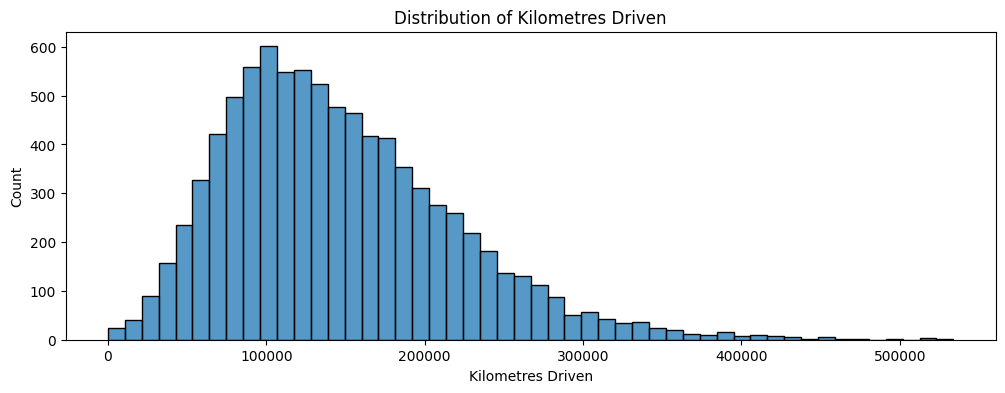

In [64]:
# distribution of kilometres driven
plt.figure(figsize=(12, 4))
sns.histplot(km_num.dropna(), bins=50)
plt.title("Distribution of Kilometres Driven")
plt.xlabel("Kilometres Driven")
plt.ylabel("Count")
plt.show()

In [65]:
# checking top and bottom km records
top10_km = training_df.assign(km_num=km_num).nlargest(10, "km_num")
print("Top 10 highest km cars:")
print(top10_km[["vehicle_brand", "model_name", "manufacturing_year", "kilometres_driven", "price", "vehicle_condition"]])

print()

bottom10_km = training_df.assign(km_num=km_num).nsmallest(10, "km_num")
print("Bottom 10 lowest km cars:")
print(bottom10_km[["vehicle_brand", "model_name", "manufacturing_year", "kilometres_driven", "price", "vehicle_condition"]])

Top 10 highest km cars:
      vehicle_brand   model_name  manufacturing_year kilometres_driven  price  \
7578  Mercedes-Benz     Sprinter              2001.0            533849   9999   
1781         Toyota        Hilux              2007.0            526162   9999   
5206           Ford       Falcon              2010.0            521771   6880   
3569         Toyota        Hilux              2006.0            520991  14900   
5223         Holden        Rodeo              2007.0            520000   7999   
3261         Toyota  Landcruiser              2008.0            512870  11998   
1232         Toyota        Hilux              2000.0            492659   7999   
3880         Toyota  Landcruiser              1999.0            473640  13988   
1226  Mercedes-Benz        MB100              2002.0            460269   1895   
7124         Nissan       Navara              2006.0            457207   7995   

     vehicle_condition  
7578              USED  
1781              USED  
5206     

In [66]:
scatter_df = pd.DataFrame({"km": km_num, "price": price_num}).dropna()
corr = scatter_df[["km", "price"]].corr().iloc[0, 1]
print(f"Correlation with price: {corr:.4f}")
points = alt.Chart(scatter_df).mark_circle(opacity=0.1, size=5).encode(
    alt.X("km:Q", title="Kilometres Driven"),
    alt.Y("price:Q", title="Price (AUD)")
)

line = alt.Chart(scatter_df).transform_regression(
    "km", "price"
).mark_line(color="red").encode(
    alt.X("km:Q"),
    alt.Y("price:Q")
)

(points + line).properties(
    title="Kilometres Driven vs Price",
    width=600,
    height=300
)


Correlation with price: -0.2657


alt.LayerChart(...)

In [67]:
feature_1_insights = """

OVERVIEW:
I think kilometres_driven is one of the most important feature to explore as the
distance driven directly affects the price of the car.

DATATYPE ISSUE:
kilometres_driven is stored as a string. I parsed it to float for analysis.
Actual typecasting will be done in Preparation notebook.

MISSING AND SUSPICIOUS VALUES:
After parsing, there were 14 missing values in training. kilometres_driven cannot
be reliably impudated as filling it with the median could be completely increse
or decrese the value of the car. These 14 records will be dropped in Preparation.
I also found 3 records with under 100 km which is suspicious for
a used car. Looking at the bottom 10 records, there is a Holden Captiva 2016 with
just 1 km listed as USED which is almost certainly a data entry error. The Nissan
Juke from year 2000 with only 6 km is listed as NEW which makes no sense at
all as a car from 2000 cannot have only 6 km run, either the manufacturing year
or the kilometres driven is wrongly entered. These suspicious records will
be flagged and handled in Preparation.

There are also 43 records over 400,000 km. Looking at the top 10 these are
all legitimate cars like Toyota Hilux, Landcruiser and Mercedes Sprinter, all in
USED condition and priced low which makes sense for high mileage working vehicles.

DISTRIBUTION:
The distribution is roughly bell shaped and slightly right skewed.
Most cars have between 50k and 250k km which makes sense for
a typical used car market.

RELATION WITH PRICE:
The correlation with price is about -0.27, negative correlation as more
kms means less price.The scatter plot shows a cone shape where low km cars
have a really wide price range but high km cars are almost all cheap. This
pattern suggests a log transform of km might help the linear models in the
experiment.

"""

In [68]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.3 Explore Feature of Interest: `manufacturing_year`


In [69]:
print("Data type:", training_df["manufacturing_year"].dtype)
print(f"Missing: {training_df['manufacturing_year'].isnull().sum()}")
print()
print(training_df["manufacturing_year"].describe().round(2))
print()
print(f"Pre-1990 vehicles: {(training_df['manufacturing_year'] < 1990).sum()}")
print(f"Pre-2000 vehicles: {(training_df['manufacturing_year'] < 2000).sum()}")

Data type: float64
Missing: 0

count    8774.00
mean     2012.46
std         4.46
min      1940.00
25%      2010.00
50%      2014.00
75%      2016.00
max      2017.00
Name: manufacturing_year, dtype: float64

Pre-1990 vehicles: 17
Pre-2000 vehicles: 119


In [70]:
# checking suspicious old vehicles
old_cars = training_df.assign(km_num=km_num)[training_df["manufacturing_year"] < 1990]
print("Vehicles manufactured before 1990:")
print(old_cars[["vehicle_brand", "model_name", "manufacturing_year", "kilometres_driven", "price", "vehicle_condition"]].to_string())

Vehicles manufactured before 1990:
      vehicle_brand model_name  manufacturing_year kilometres_driven    price vehicle_condition
2           Porsche        911              1978.0            145600    97500              USED
476           Honda        Fit              1981.0             43749    19490              USED
793          Nissan    Skyline              1989.0             41489    72888              USED
1078        Ferrari        250              1959.0              9902  1500000              USED
1408  Mercedes-Benz        190              1989.0            150426    19990              USED
1998         Holden        HDT              1984.0            204733   148880              USED
3301  Mercedes-Benz        420              1989.0            170744    24990              USED
3720          Honda        Fit              1981.0             60400    19600              USED
4892         Datsun     Stanza              1979.0             99999    29888              USED
4969 

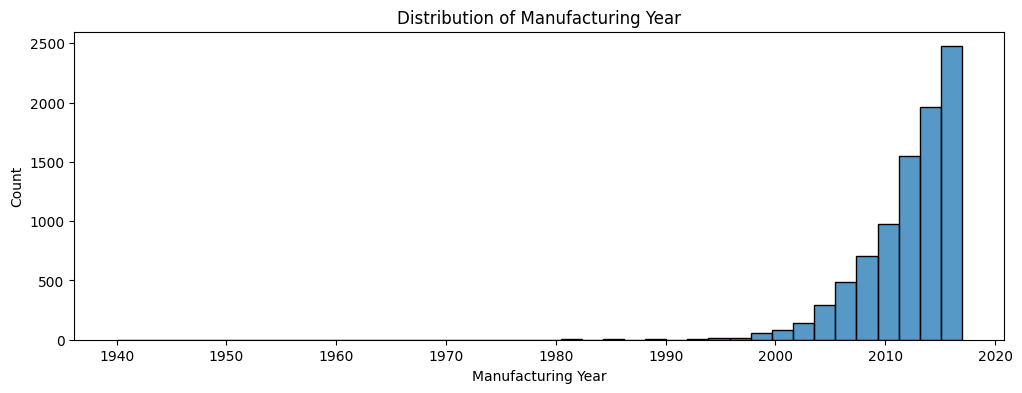

In [71]:
# distribution of manufacturing year
plt.figure(figsize=(12, 4))
sns.histplot(training_df["manufacturing_year"].dropna(), bins=40)
plt.title("Distribution of Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Count")
plt.show()

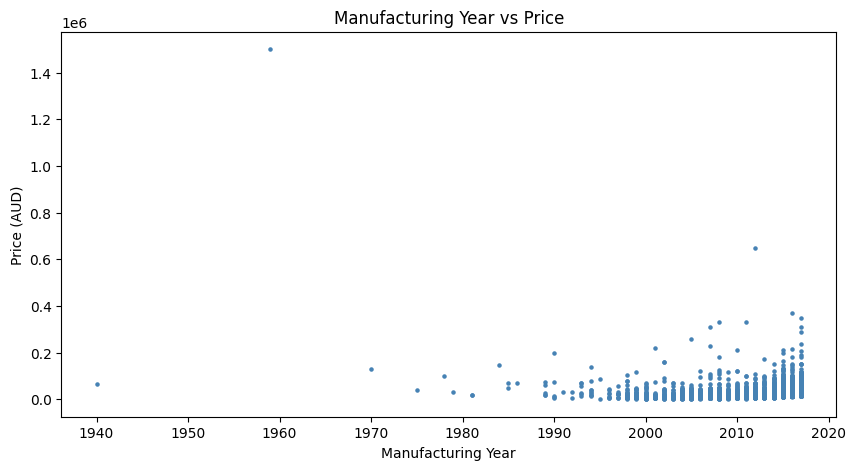

Correlation with price: 0.1045


In [72]:
year_price_df = pd.DataFrame({
    "year": training_df["manufacturing_year"],
    "price": price_num
}).dropna()
plt.figure(figsize=(10, 5))
plt.scatter(year_price_df["year"], year_price_df["price"], s=5, color="steelblue")
plt.title("Manufacturing Year vs Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Price (AUD)")
plt.show()

corr = year_price_df[["year", "price"]].corr().iloc[0, 1]
print(f"Correlation with price: {corr:.4f}")

In [73]:
feature_2_insights = """

OVERVIEW:
In manufacturing_year, the expectation was to see linear dependance as newer
cars are worth more than older ones, but as few vintage collections are present
it deviates from the original assumptions.

DATA TYPE AND MISSING VALUES:
manufacturing_year is stored as float64 which is incorrect, it should
be an integer. There are no missing values so this will be cast to int
in Preparation notebook.

DISTRIBUTION:
The majority of cars in the dataset are from 2000 to 2017. There are very
few cars before 1990, only 17 in total. The dataset is heavily skewed towards
recent vehicles.

SUSPICIOUS VALUES:
I looked at all 17 vehicles manufactured before 1990 and they are
actually all legitimate cars, 1940 Packard, 1959 Ferrari 250, and various old
collectables. These are genuine vintage vehicles with prices ranging
from $19,490 to $1,500,000. None of these are data entry errors.

As the classic collectables price depends on the demand, hype of that perticular
brand or design, it is difficult to club them together with regualr cars and
scale their price based on kilometers driven or the manufacturing year etc.

RELATION WITH PRICE:
The correlation with price is only +0.10 which is weak but understandbale as the
collectables such as the 1959 Ferrari at $1.5M is affecting the relation.

"""

In [74]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.4 Explore Feature of Interest: `body_type`


In [75]:
print("Data type:", training_df["body_type"].dtype)
print(f"Missing: {training_df['body_type'].isnull().sum()}")
print()
print(training_df["body_type"].value_counts())

Data type: object
Missing: 197

body_type
SUV             2915
Hatchback       1495
Ute / Tray      1349
Sedan           1311
Wagon            806
Commercial       365
Coupe            222
Convertible       99
People Mover      15
Name: count, dtype: int64


In [76]:
counts = training_df["body_type"].value_counts(dropna=False).reset_index()
counts.columns = ["body_type", "count"]
counts["body_type"] = counts["body_type"].fillna("Missing")

alt.Chart(counts).mark_bar().encode(
    alt.Y("body_type:N", sort="-x", title="Body Type"),
    alt.X("count:Q", title="Count"),
    tooltip=["body_type", "count"]
).properties(
    title="Distribution of Body Types (including missing)",
    width=500,
    height=300
)

alt.Chart(...)

In [77]:
# median price per body type
body_price = training_df.assign(price_num=price_num).groupby("body_type")["price_num"].median().reset_index()
body_price.columns = ["body_type", "median_price"]

alt.Chart(body_price).mark_bar().encode(
    alt.Y("body_type:N", sort="-x", title="Body Type"),
    alt.X("median_price:Q", title="Median Price (AUD)"),
    tooltip=["body_type", "median_price"]
).properties(
    title="Median Price by Body Type",
    width=500,
    height=300
)

alt.Chart(...)

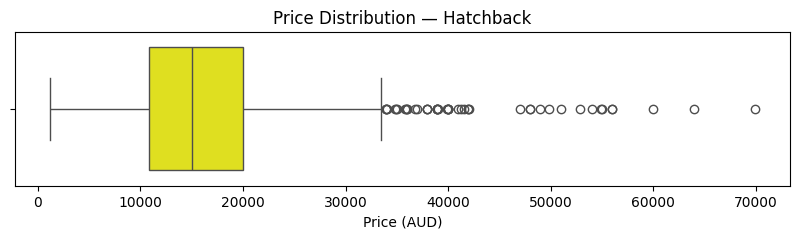

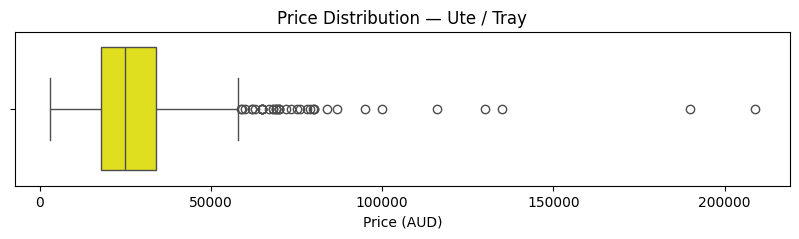

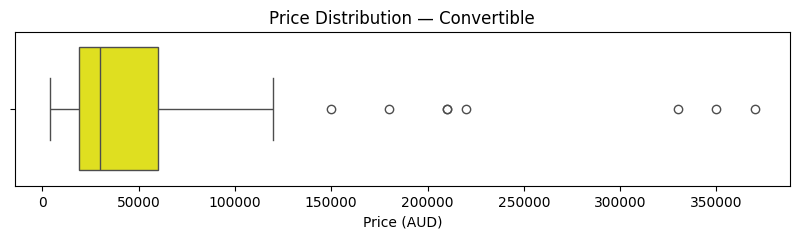

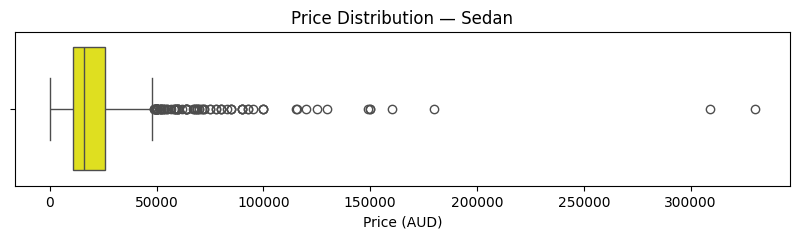

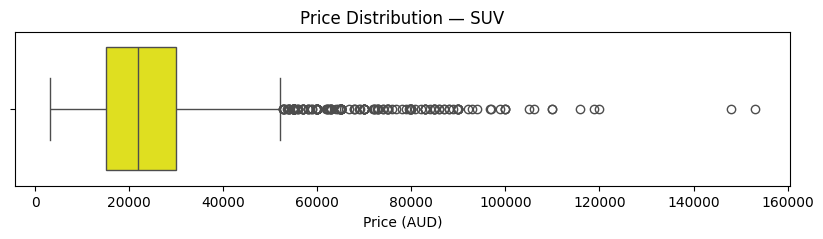

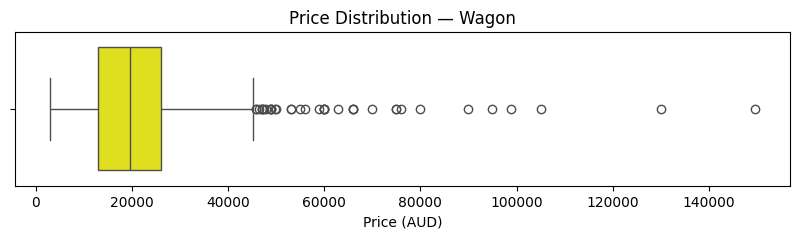

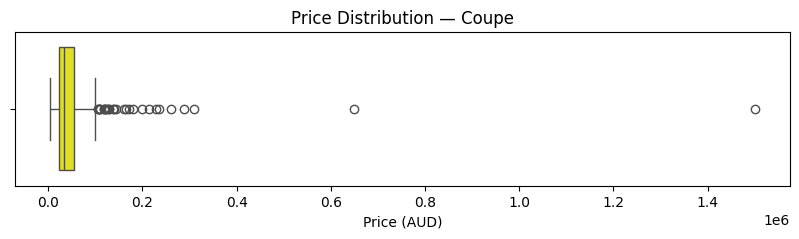

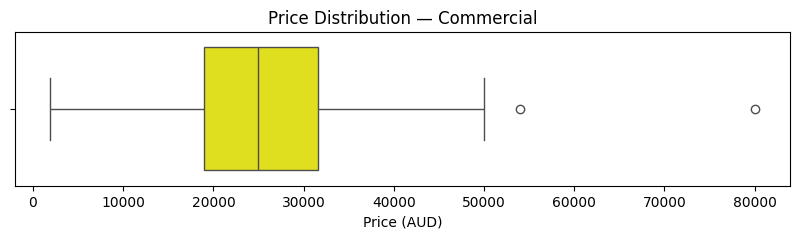

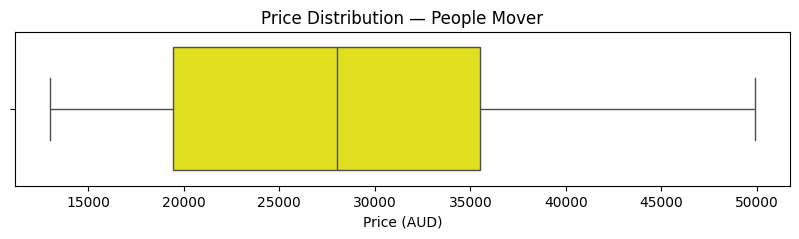

In [78]:
for body in training_df["body_type"].dropna().unique():
    body_df = training_df.assign(price_num=price_num)
    body_df = body_df[body_df["body_type"] == body][["body_type", "price_num"]].dropna()

    plt.figure(figsize=(10, 2))
    sns.boxplot(x="price_num", data=body_df, color="yellow")
    plt.title(f"Price Distribution — {body}")
    plt.xlabel("Price (AUD)")
    plt.show()

In [79]:
feature_3_insights = """

OVERVIEW:
body_type is one of the more interesting categorical features because
different body types attract different types of buyers and varies in price.

DATA TYPE AND MISSING VALUES:
body_type is stored as object which is fine for a categorical column.
There are 197 missing values which will be imputed with the mode
(SUV) in Preparation since we cannot determine the body type using other features.

DISTRIBUTION:
There are 9 unique body types. SUV dominates with 2,915 records,
followed by Hatchback (1,495), Ute/Tray (1,349) and Sedan (1,311).
People Mover is the rarest with only 15 records which means the model will
have very little data to learn from for that category.

RELATION WITH PRICE:
Looking at the median price chart, Coupes are the most expensive
at around $33,000 followed by Convertibles and People Movers.
Hatchbacks are the cheapest at around $15,000.

The individual boxplots tells more about the same. Coupe has the widest
price range stretching all the way to $1.5M because it includes
exotic sports cars like the Ferrari. Convertible also is a popular choice and
has a wide range up to $370k. Hatchback and Sedan are tightly clustered at the
lower end.

"""

In [80]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.5 Explore Feature of Interest `vehicle_brand`


In [81]:
print("Data type:", training_df["vehicle_brand"].dtype)
print(f"Missing: {training_df['vehicle_brand'].isnull().sum()}")
print(f"Unique brands: {training_df['vehicle_brand'].nunique()}")
print()
print(training_df["vehicle_brand"].value_counts())

Data type: object
Missing: 0
Unique brands: 66

vehicle_brand
Toyota     1430
Holden      916
Ford        682
Nissan      667
Mazda       619
           ... 
Hummer        1
Daewoo        1
Datsun        1
Packard       1
Proton        1
Name: count, Length: 66, dtype: int64


In [82]:
# distribution of brands
brand_counts = training_df["vehicle_brand"].value_counts().reset_index()
brand_counts.columns = ["vehicle_brand", "count"]

alt.Chart(brand_counts).mark_bar().encode(
    alt.Y("vehicle_brand:N", sort="-x", title="Brand"),
    alt.X("count:Q", title="Count"),
    tooltip=["vehicle_brand", "count"]
).properties(
    title="Vehicle Brand Distribution",
    width=500,
    height=800
)

alt.Chart(...)

In [83]:
# median price per brand
brand_price = training_df.assign(price_num=price_num).groupby("vehicle_brand")["price_num"].median().reset_index()
brand_price.columns = ["vehicle_brand", "median_price"]
brand_price = brand_price.sort_values("median_price", ascending=False)

alt.Chart(brand_price).mark_bar().encode(
    alt.Y("vehicle_brand:N", sort="-x", title="Brand"),
    alt.X("median_price:Q", title="Median Price (AUD)"),
    tooltip=["vehicle_brand", "median_price"]
).properties(
    title="Median Price by Brand",
    width=500,
    height=800
)

alt.Chart(...)

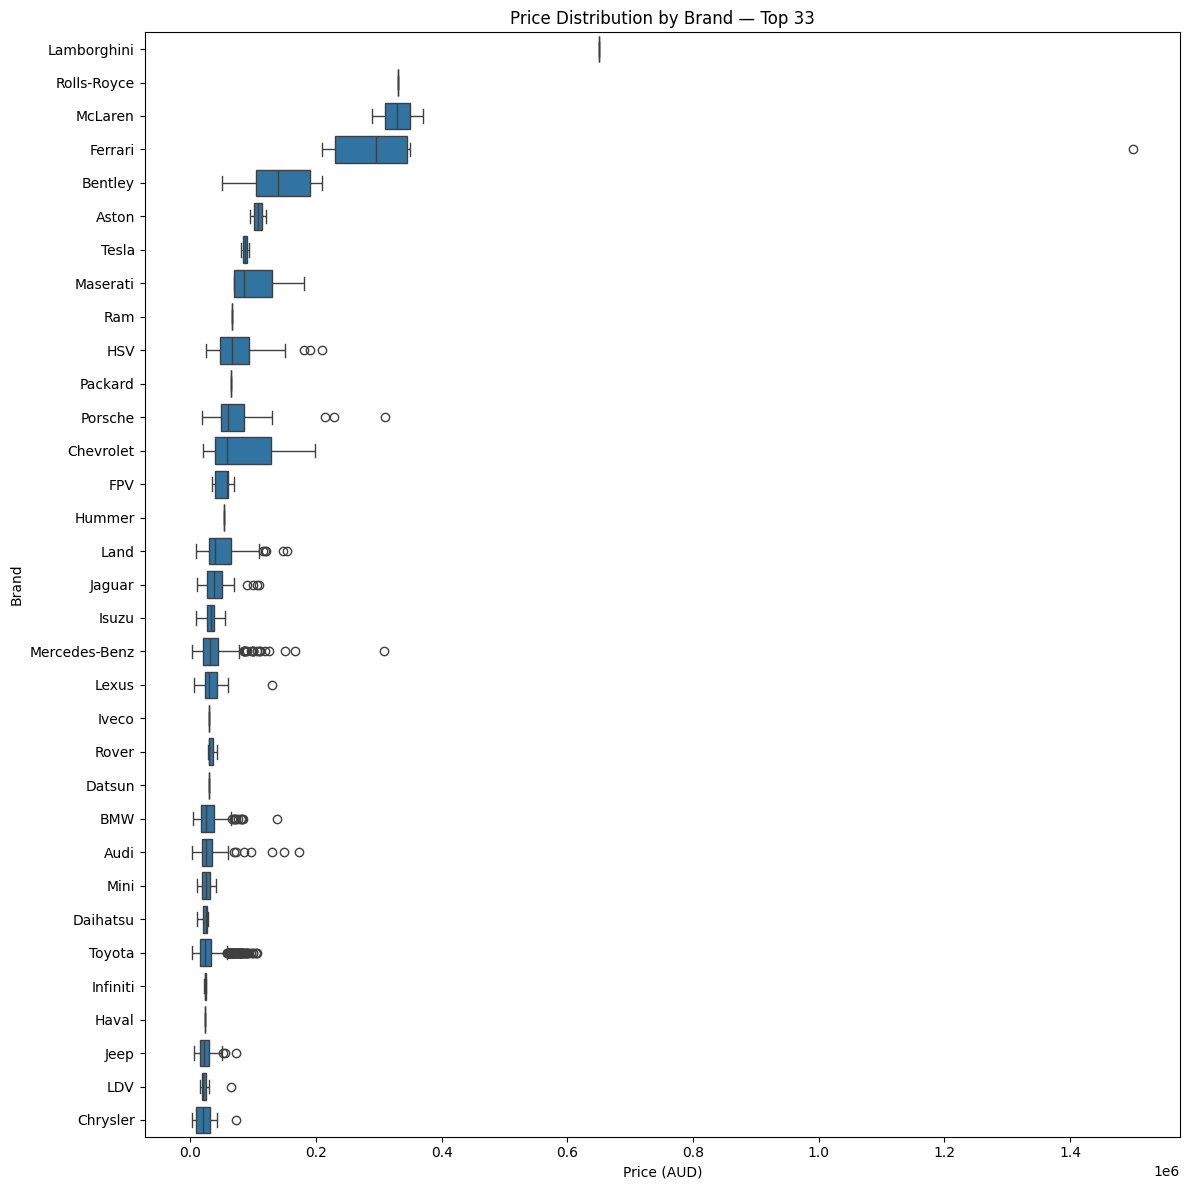

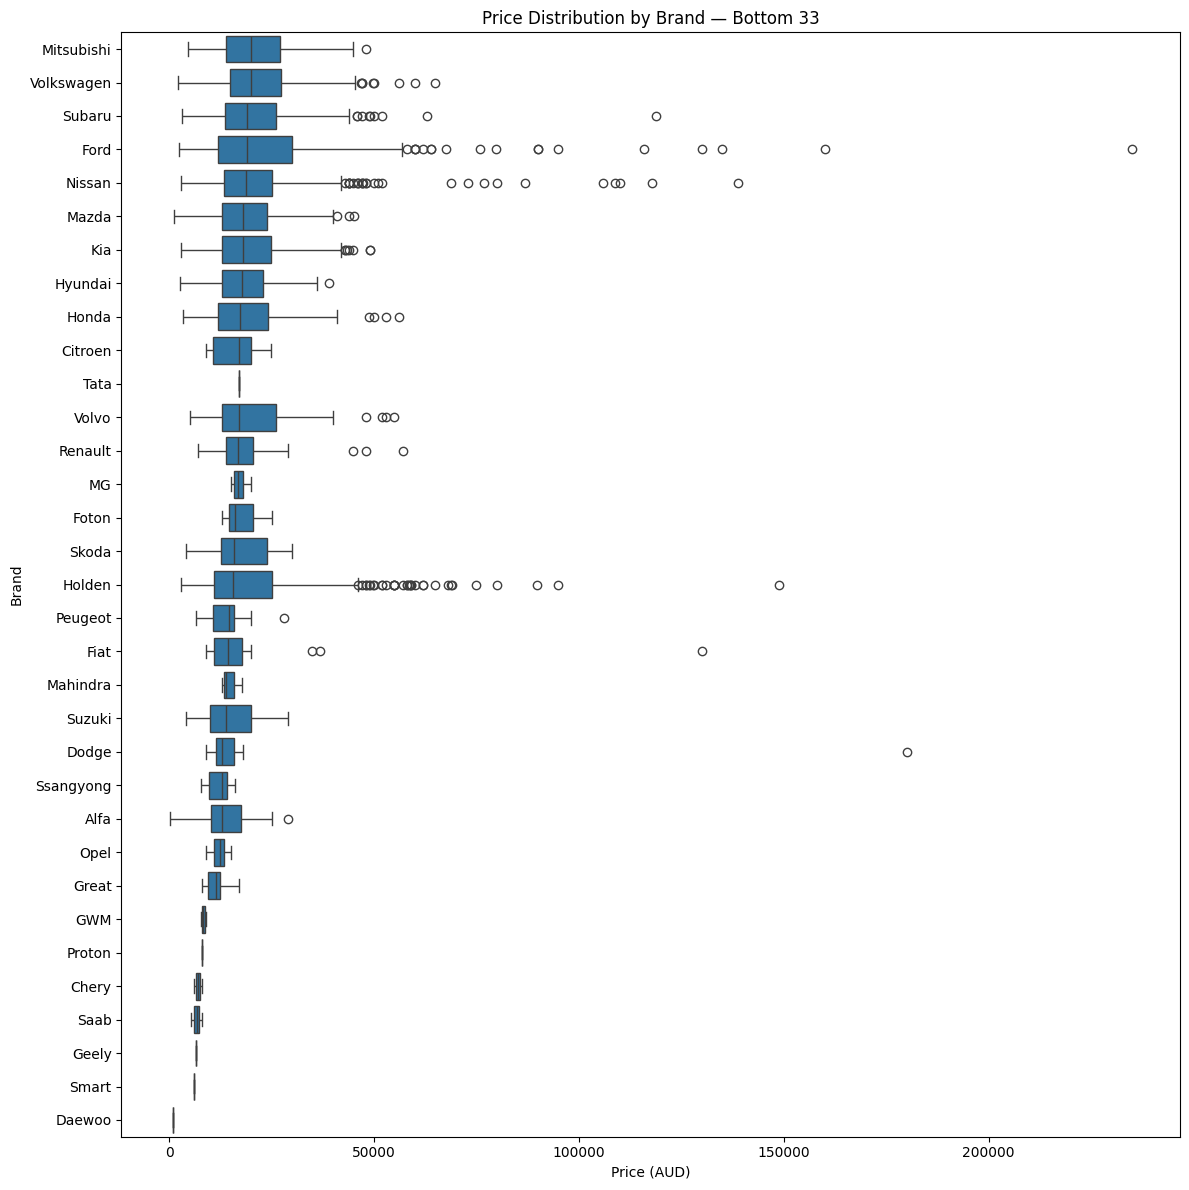

In [84]:
brand_order = brand_price.sort_values("median_price", ascending=False)["vehicle_brand"].tolist()
brand_box_df = training_df.assign(price_num=price_num)[["vehicle_brand", "price_num"]].dropna()

# top 33 brands by median price
fig, ax = plt.subplots(figsize=(12, 12))
sns.boxplot(x="price_num", y="vehicle_brand",
            data=brand_box_df[brand_box_df["vehicle_brand"].isin(brand_order[:33])],
            order=brand_order[:33], ax=ax)
ax.set_title("Price Distribution by Brand — Top 33")
ax.set_xlabel("Price (AUD)")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.show()

# bottom 33 brands by median price
fig, ax = plt.subplots(figsize=(12, 12))
sns.boxplot(x="price_num", y="vehicle_brand",
            data=brand_box_df[brand_box_df["vehicle_brand"].isin(brand_order[33:])],
            order=brand_order[33:], ax=ax)
ax.set_title("Price Distribution by Brand — Bottom 33")
ax.set_xlabel("Price (AUD)")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.show()

In [85]:
feature_4_insights = """

vehicle_brand is one of the most important signals for price as the brand name
would influence the price of the car but that alone is not a strong factor.

MISSING VALUES AND DATATYPE:
vehicle_brand is of object datatype. There were no missing values found.

OBSERVATION:
There are 66 distinct brands in the data set. Most cars are of toyota, Holden
and Ford. Brands like Hummer, Daewoo, and Datsun have just 1 record each.

RELATION WITH PRICE:
The median price chart shows a clear pricing hierarchy. Lamborghini
sits at the top followed by Rolls-Royce, McLaren and Ferrari. At the
bottom are budget brands like Daewoo, Smart and Chery.

The split boxplots reveal something interesting:
Top 33 (expensive) brands: Lamborghini and Rolls-Royce have extremely
broad price ranges with nearly no IQR visible, indicating that model and
condition have a greater influence on costs than brand alone.
The 1959 Ferrari 250 is a huge anomaly for Ferrari at $1.5 million.

Bottom 33 brands (affordable): The majority of popular brands, such as Toyota,
Holden, Ford, and Nissan have a lot of outliers, which means that while most
cars are in a predictable range, there are a few exceptions.

ENCODING:
Vehicle_brand and body_type will be joined to form a new feature called
brand_bodytype in the Preparation notebook because brand alone can be deceptive
(a Toyota SUV and Toyota Hatchback are priced considerably differently).
The smoothed mean prices from training will then be used to target encode this.
encoded = (n * brand_mean + k * global_mean) / (n + k), where k is a smoothing
factor and n is the number of records for that brand. While popular brands will
maintain their unique pricing signal, rare names will have their mean moved
towards the global average to avoid overfitting.

"""

In [86]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.6 Explore Feature of Interest `transmission_type`


In [87]:
print("Data type:", training_df["transmission_type"].dtype)
print(f"Missing: {training_df['transmission_type'].isnull().sum()}")
print()
print(training_df["transmission_type"].value_counts())

Data type: object
Missing: 0

transmission_type
Automatic    7125
Manual       1548
-             101
Name: count, dtype: int64


In [88]:
counts = training_df["transmission_type"].value_counts().reset_index()
counts.columns = ["transmission_type", "count"]

alt.Chart(counts).mark_bar().encode(
    alt.Y("transmission_type:N", sort="-x", title="Transmission Type"),
    alt.X("count:Q", title="Count"),
    tooltip=["transmission_type", "count"]
).properties(
    title="Distribution of Transmission Type",
    width=400,
    height=200
)

alt.Chart(...)

In [89]:
# median price per transmission type
trans_price = training_df.assign(price_num=price_num).groupby("transmission_type")["price_num"].median().reset_index()
trans_price.columns = ["transmission_type", "median_price"]

alt.Chart(trans_price).mark_bar().encode(
    alt.Y("transmission_type:N", sort="-x", title="Transmission Type"),
    alt.X("median_price:Q", title="Median Price (AUD)"),
    tooltip=["transmission_type", "median_price"]
).properties(
    title="Median Price by Transmission Type",
    width=400,
    height=200
)

alt.Chart(...)

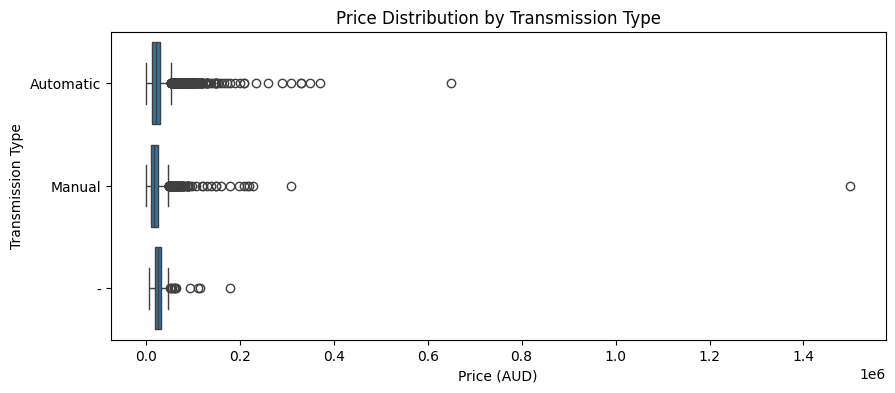

In [90]:
# boxplot per transmission type
trans_box_df = training_df.assign(price_num=price_num)[["transmission_type", "price_num"]].dropna()

plt.figure(figsize=(10, 4))
sns.boxplot(x="price_num", y="transmission_type", data=trans_box_df)
plt.title("Price Distribution by Transmission Type")
plt.xlabel("Price (AUD)")
plt.ylabel("Transmission Type")
plt.show()

In [91]:
feature_5_insights = """

transmission_type has values: Automatic, Manual and dash(placeholders). When I ran isnull().sum()
it showed 0 missing values because there are no NaN or empty cells. However 101 records have a dash as
the value which is being used as a placeholder for unknown transmission type. These will be replaced
with the mode which is Automatic in Preparation.

DISTRIBUTION:
Automatic dominates over manual with 7,125 records.This shows the preference in the market for usage
of automatic cars.

RELATION WITH PRICE:
Looking at the median price chart, the dash category actually has the highest median price. Automatic
has a higher median than Manual at around $21,000 vs $18,000 which makes sense as automatic cars are
generally more desirable in Australia.

"""

In [92]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

### C.7 Explore other Features of Interest `"drive_type", "engine_cylinders", "seats", "doors"`


In [93]:
for col in ["drive_type", "engine_cylinders", "seats", "doors"]:
    print(f"=== {col} ===")
    print(f"Missing: {training_df[col].isnull().sum()}")
    print(training_df[col].value_counts())
    print()

=== drive_type ===
Missing: 0
drive_type
Front    3219
4WD      1745
Rear     1686
AWD      1377
Other     747
Name: count, dtype: int64

=== engine_cylinders ===
Missing: 0
engine_cylinders
4 cyl     5564
6 cyl     1412
-         1080
8 cyl      384
5 cyl      265
3 cyl       48
12 cyl      10
0 L          5
2 cyl        4
10 cyl       2
Name: count, dtype: int64

=== seats ===
Missing: 1103
seats
5 Seats     5630
7 Seats      877
4 Seats      412
2 Seats      370
3 Seats      191
8 Seats      159
6 Seats       17
14 Seats      11
11 Seats       3
9 Seats        1
Name: count, dtype: int64

=== doors ===
Missing: 1036
doors
4 Doors     5602
5 Doors     1241
2 Doors      709
3 Doors      142
5 Seats       11
6 Seats        8
8 Seats        7
7 Seats        5
2 Seats        4
9 Seats        3
4 Seats        3
3 Seats        2
12 Seats       1
Name: count, dtype: int64



In [94]:
# median price for each remaining feature
for col in ["drive_type", "engine_cylinders", "seats", "doors"]:
    col_price = training_df.assign(price_num=price_num).groupby(col)["price_num"].median().reset_index()
    col_price.columns = [col, "median_price"]

    display(alt.Chart(col_price).mark_bar().encode(
        alt.Y(f"{col}:N", sort="-x", title=col),
        alt.X("median_price:Q", title="Median Price (AUD)"),
        tooltip=[col, "median_price"]
    ).properties(title=f"Median Price by {col}", width=400, height=250))

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [95]:
remaining_feature_insights = """

For drive_type:
No missing values observed . Front wheel drive is most common followed by 4WD, Rearand AWD.
There are 747 records with Other category. 4WD and AWD have the highest median prices at
around $25,000 as these are typically SUVs and utes. Front wheel drive has the lowest median at around
$16,000 reflecting economy cars. This feature has a clear relationship with price and will be kept
for modelling.

For engine_cylinders:
No actual null values but 1,080 records have a dash placeholder and 5 records show 0 L which is invalid.
Similar to transmission_type, these are unknown values not genuine nulls. More cylinders clearly means
higher price - 12 cyl has a median over $120,000 while 3 cyl sits at the bottom. This is a strong signal
and will be kept. The dash and 0 L values will be treated as missing and imputed with the mode in Preparation.

For seats:
1,103 missing values which is already high at 12.6%. Looking at the distribution, there are 11 records
with 14 seats, 3 with 11 seats and 1 with 9 seats. A regular car simply cannot have that many seats.
This is either a minibus which should not be in a used car dataset or a data entry error. Even 8 seats
is borderline. On top of that the signal seats adds is largely already captured by body_type, a
Coupe will always be a 2 seater, a People Mover will always be 7+. Given the high missing rate, suspicious
values and redundancy with body_type, this column will be dropped in Preparation.

For doors:
1,036 missing values at 11.8%. More critically the doors column has corrupted data, there are seat values
like 5 Seats, 6 Seats, 8 Seats mixed in with actual door counts like 2 Doors, 4 Doors. Someone
clearly entered seat information in the wrong column. Similar to
seats, the information doors provides is largely already captured by body_type. Given the data corruption,
high missing rate and redundancy, this column will also be dropped in Preparation.

"""

In [96]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='remaining_feature_insights', value=remaining_feature_insights)